# Capstone: Generating Ad text for Amazon shopping 



### **Problem Satatement**


### Contents:
- [Problem Statement](#Problem-Statement)
- [Summary](#Summary)
- [Data Dictionary](#Data-Dictionary)
- [Methodology](#Methodology)
- [Findings and Observations](#Findings-and-Observations)
- [Cross-Post](#Cross-Post)
- [Best Models](#Best-Models)
- [Conclusions](#Conclusions)
- [Next Steps](#Next-Steps)
- [Bibliography](#Bibliography)


#### Problem Statement<a class="anchor" id="Problem-Statement"></a>

Amazon’s 6 million Sellers want to generate creative and fresh ads quickly and efficiently to promote their products on the Amazon web site. Current methods require much manual creation of the advertisement text and it is cumbersome for large Sellers who have many thousands of listed products. Fast moving items like consumer electronics are updated frequently and the ads need to be updated equally quickly. 

This is a large business opportunity and a few startups have begun using Natural Language Generation (NLG) technology to auto-generate text including Ads. The model can be easily fine-tuned for Ads for Google, Facebook, Bing and other e-commerce platforms, as well as many sentence completion applications like Quora Question Answer, personalised review generator, email subject lines and other marketing content. These GPT models also do a decent job in writing code! 

An AI startup has asked me to come up with a pilot project. 

#### Summary<a class="anchor" id="Summary"></a>
Given that State of the Art models like OpenAI's GPT3 and EleutherAI's GPT-NEOs are trained on billions of parameters and cost upwards of $10M to train, how good can our RNN LSTM model really be?   
How much data is sufficient and what e-commerce verticals work best?   
How does the model compare with these Large Language models?  
Can we use our dataset to fine-tune these pre-trained models?   
How well does our fine-tuned model perform?   
What metrics can be used to evaluate the model?  

Using advertisement data for Amazon Ads 
2 domains
add holiday text


#### Data Dictionary<a class="anchor" id="Data-Dictionary"></a>

<https://www.kaggle.com/datasets/sachsene/amazons-advertisements> from <https://github.com/paschok/Diploma>

The dataset size is 252 MB and comprises of 2.7 million ad texts (each is one row in the csv) in 445 files across 40 categories like electronics, wearables, automotive, appliances, fashion, tools, accessories etc. 

#### Input Data
Decided to use only 2 domains (electronics and wearables) since I could only use about 10-15K rows of training data without running into resource constraints. 

* [`amazon_tv_wearable_12k_holidays.csv`](../data/amazon_tv_wearable_12k_holidays.csv): Ad text data from amazon.com shopping

**Samples of ad text:** 

Sony SWR50 SmartWatch 3 Transflective Display Watch [Black]  
Sony SmartWatch US version 1 Android Bluetooth USB Retail Box  
Sony HDRAS20/B Action Video Camera  
Sony DVPSR510H DVD Player, with HDMI port (Upscaling)  
Sony UBP-X700 4K Ultra HD Blu-Ray Player  
Sony STRDH590 5.2 multi-channel 4k HDR AV Receiver with Bluetooth 
Sony BDPS3700 Streaming Blu-Ray Disc Player with Wi-Fi (Black)  
Apple Watch Series 3 (GPS), 42mm Space Gray Aluminum Case with Black Sport Band - MQL12LL/A (Renewed)  
Apple Watch Series 4 (GPS + Cellular, 40mm) - Gold Aluminium Case with Pink Sand Sport Band (Renewed)  
Apple Watch Screen Protector [2 Pack] Premium 3D Tempered Glass Screen Protector for iWatch 42mm Series 3 2 1-[Full Coverage][HD Clear][Scratch-Resistant][Anti Bubble]  
Samsung Gear S2 Smartwatch - Dark Gray  
Samsung HMD Odyssey+ Windows Mixed Reality Headset with 2 Wireless Controllers 3.5" Black (XE800ZBA-HC1US)  
Samsung Galaxy Watch (42mm) Smartwatch (Bluetooth) Android/iOS Compatible -SM-R810 (Rose Gold)  
Samsung Galaxy Fit Black (Bluetooth), SM-R370NZKAXAR ‚Äì US Version with Warranty  
Samsung Galaxy Smartwatch (46mm) Silver (Bluetooth), SM-R800NZSAXAR ‚Äì US Version with Warranty  
GE Universal Remote Control for Samsung, Vizio, LG, Sony, Sharp, Roku, Apple TV, RCA, Panasonic, Smart TVs, Streaming Players, Blu-ray, DVD, Simple Setup, 4-Device, Graphite, 33711  
Dell Mobile Projector M318WL 500 ANSI lumens WXGA (1280 x 800) 16:10  
Full Motion Tilt, Pan, Swivel Desktop Mount for 32" Samsung, LG, Dell, ViewSonic, HP LED TV/Monitor  
Casio WSD-F10 Smart Outdoor Watch  
Casio Men's 'Pro Trek' Resin Outdoor Smartwatch, Color:Orange (Model: WSD-F20-RGBAU)  
[5-Pack] For Casio GST-B100 Watch Screen Protector,Full Coverage Screen Protector for GST-B100 / GST-B100-1ACR/GST-B100X-1AJF/GST-B100D-1ACR HD Clear Anti-Bubble and Anti-Scratch  
AmazonBasics USB 3.0 to 10/100/1000 Gigabit Ethernet Internet Adapter  
AmazonBasics Amplified Indoor/Outdoor TV Antenna - 60 Mile Range  
AmazonBasics TV Trolley for 24-43" TVs with Swivel Feature  
NVIDIA SHIELD TV Gaming Edition | 4K HDR Streaming Media Player with GeForce NOW  
Geekworm NVIDIA Jetson Nano WiFi Adapter Dual Band Wireless USB 3.0 Adapter 5GHz and 2.4GHz 1200Mbps Network Card  


#### Intermediate Data files

To provide a cleaner break between the different facets of modeling and to permit simpler navigation across notebooks, I created a number of intermediate files. These files are used in the model training and evaluation in notebooks 2 and 3. 

**Model evaluation metrics**

* [`lstm_results_df.csv`](../data/lstm_results_df.csv): Ad text data from amazon.com 



#### Output Data files

* [`pytorch_model.bin`](../data/AdTextGenerator/pytorch_model.bin): Model fine-tuned on the amazon ads dataset on top of the pre-trained EleutherAI/gpt-neo-125M model.    


Published my model to the open-source “GitHub of machine learning” HuggingFace -  <a href="https://huggingface.co/nirajsaran/AdTextGenerator" target="_blank">My AdTextGenerator</a> for interactive online ad text generation or use by others for further downstream fine-tuning.   

* [`config.json`](../data/AdTextGenerator/config.json): Config file for the above 
  
* [`lstm_model_13krows_batch4k.h5`](../data/lstm_model_13krows_batch4k.h5): My trained RNN LSTM model 
* [`lstm_model_emb_13k_batch4k.h5`](../data/lstm_model_emb_13k_batch4k.h5): My trained model with embedding layer
  

#### Image files
For presentation purposes



### Outside Research
Word Level text generation using RNN LSTM.  
Fine-tuning a pre-trained model on Google Colab with GPU.  
Uploading a model to HuggingFace and customizing the model-card for model parameters and example texts.   




### The notebook can be run on the local machine or on Google Colab. Set the global variables accordingly

In [1]:

# Set global variables 
# Set to True if using Google colab or set to False if using the local machine
onGoogleColab = False

# Separate variable if using GPU on Colab because the GPU is not always available and is not needed 
# if the model is already trained and being used for inference
useGPU = False # set to False if using local machine

# Use TPU 
useTPU = False 

max_rows= 15000 # limit the number of input observations to avoid going Out Of Memory (OOM) 
batch_size = 4096 # Tried various batch_sizes from 256 upto 4k. 4k gives the least loss but requires the most memory
layer_size = 128

In [2]:
# Mount Google Drive. Pops up an authentication window. Connect your Google account and grant permissions. 
# This is not needed for local machine
if onGoogleColab: 

  from google.colab import drive
  drive.mount('/content/drive')
  %cd drive/MyDrive/Colab\ Notebooks/nlg/code
  %pwd

In [3]:
if onGoogleColab:
  !pip install transformers

In [8]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import datetime as dt
#import re

from preprocess_tokenize import * # helper .py file
from modeling_functions import * # helper .py file
#from collections import Counter

import tensorflow as tf

from tensorflow.keras.utils import Sequence 

#from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding

#from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

#from tensorflow.keras.callbacks import EarlyStopping

from transformers import pipeline

#### Read input data from the amazon ad text file.   
This contains data from Amazon ads for two categories Electronics and Wearables. I also added a few rows for holiday related special deals and discounts to support additional ad formats. 

In [9]:
# Read data

file_name = "../data/amazon_tv_wearable_12k_holidays.csv"

df_ads = pd.read_csv(file_name)

df_ads.head() # contains just one column


,ad
0,Spigen Rugged Armor Pro Designed for Apple Wat...
1,Xiaomi Mi Band 4
2,LK 6 Pack Screen Protector for Apple Watch (38...
3,KOLEK Floral Bands Compatible with Apple Watch...
4,Amazfit Bip Smartwatch by Huami with All-Day H...


In [10]:
df_ads.describe()

,ad
count,13070
unique,12880
top,ANCOOL Compatible with Fenix 6 Pro Bands Soft ...
freq,13


### Data Cleanup 
- punctation, numbers, model numbers (words containing digits) 


In [11]:
df_ads.dropna(inplace=True) # drop the nulls, if any

In [12]:
df_ads.loc[df_ads["ad"].str.contains("Casio")].head()

,ad
1882,Casio Men's 'Pro Trek' Resin Outdoor Smartwatc...
2265,[5-Pack] For Casio DW-5600 /DW5600 Watch Scree...
2699,[5-Pack] for Casio MDV106-1A Watch Screen Prot...
2968,23mm Rubber Watch Band Strap Fits Casio Replac...
3268,SIKAI Protective Bumper for Casio G-Shock GW56...


In [13]:
len( set( df_ads["ad"] ) ) # 12880 unique rows out of 13070

12880

In [14]:
# Remove the dups and store back in df
df_ads = pd.DataFrame(list( set( df_ads["ad"] ) ), columns = ["ad"] )
df_ads


,ad
0,Eighwood Dual Band UHF VHF Antenna NMO Mount f...
1,EXC Compatible Fitbit Versa Screen Protector [...
2,findway Compatible with Fitbit Ace 2 Bands for...
3,SIIG USB 3.0 to Gigabit Ethernet 10/100/1000 M...
4,"Bluetooth Smart Watches, KKCITE Waterproof Fit..."
...,...
12875,Shangpule Compatible for Fitbit Charge 3 & Cha...
12876,Callancity Metal Protective Face Cover Bezel C...
12877,Winegard FL-55YR FlatWave Amplified Razor Thin...
12878,"Fitbit Ionic Charger, KingAcc Replacement USB ..."


#### EDA

- Only one column of information



Text(0.5, 1.0, 'Frequency of number of characters per ad')

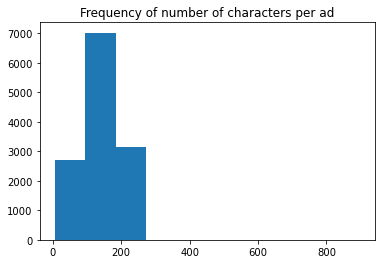

In [15]:
# Look at the data

plt.hist([len(s) for s in df_ads["ad"]]);
plt.title("Frequency of number of characters per ad")


In [16]:
# add column with len of ad text

df_ads["num_chars"] = [len(s) for s in df_ads["ad"]]

df_ads['num_chars']


0         87
1        199
2        165
3        123
4        184
        ... 
12875    144
12876     99
12877     76
12878    180
12879    104
Name: num_chars, Length: 12880, dtype: int64

In [17]:
df_ads['num_chars'].describe()

count    12880.000000
mean       140.190295
std         51.297043
min          6.000000
25%        105.000000
50%        152.000000
75%        183.000000
max        896.000000
Name: num_chars, dtype: float64

In [18]:
df_ads['num_chars'].value_counts()

198    272
199    270
200    268
197    237
196    205
      ... 
205      1
206      1
470      1
342      1
279      1
Name: num_chars, Length: 229, dtype: int64

In [19]:
pd.set_option ('display.max_colwidth', 350) 

df_ads.loc[df_ads['num_chars'] > 300]

,ad,num_chars
1845,"Brand NEW original seiki SEIKI TV Remote for SEIKI LC-32GC12F LC-46G68 SC552GS SC324FB SC32HT04 SE32HS01 SE65FY18 SE60GY24 SE65JY25 SE19HT01 SE40FY19 SE50UY04 LE-46GCA LE-55G77E SE39UY04 SE47FY19 LE-32SCL-C SE55UY04 SC22HY07 TV REMOTE----Original remote; do not any setting, only put into battery can work!",306
3848,"Original TV remote control for LG 3D AKB73615362=AKB73615397 *UNIVERSAL* 100% replacement for AKB73615303, AKB73615397 and AKB73756542. HIGH QUALITY Remote. It is a perfect solution if you dont want to use LG MAGIC AN-MR400 remote. Suitable models: AKB73615303, AKB73615362, AKB73615302, AKB73756542, AKB73615361, AKB73615362",325
3925,Brand NEW Original INSIGNIA TV remote control NS-RC4NA-14 RC4NA14 Remote For NS-28ED200NA14 NS-50D400NA14 NS-19ED200NA14 55E4400A14 NS-58E4400A14 NS-24E400NA14 NS-60E4400A14 NS-65E4400A14 NS-50L440NA14 NS-46D400NA14 NS-65D4400A14 NS-22E400NA14 NS-46L400NA14 NS-46E440NA14 NS-32E2000A14 NS-39D400NA14 NS-32DD2000A14 NS-39L400NA14 NS-55E4400A14 NS-...,426
5710,"Mount-It! MI-1121M Slim Tilt TV Wall Mount Bracket for LED LCD Plasma Flat Screen Panels for 32‚Äù to 65‚Äù (Many from 20-75‚Äù) up to VESA 600 x 400 and 130 lbs Low Profile. 0-15 Degree Forward Adjustable Tilting and Leveling Bubble Fits Samsung, Sony, LG Sharp, Insignia, Vizio, Haier 26, 28, 32, 40, 42, 48, 49, 50, 51, 52, 55, 60, 65 inch TV,...",352
5881,NEW Remote fit for VIZIO E320i-B0 E390i-A1 E401i-A2 E480i-B2 E470i-A0 E480-B2 E500D-A0 E291IA1 E320IB0 E390IA1 E401IA2 E550I-B2 E470i-A0 E480IB2 E500DA0 E500I-A1 E550I-A0 E420I-A0 E390I-A1 E320I-A0 E241I-A1 E470I-A0-B E420I-A0-B E390I-A1B E241I-A1B E500I-B1E E420i-A0 E320i-A0 E320I-A2 E322AR E422AR E502AR and most App internet LCD and LED TV---...,372
6099,NEW SEIKI TV Remote control for SEIKI SE55GY19 SE65UY04 SE22FE01 SE65GY25 SE40FY27 SE32FY22 TV SE24FE01-W SE19HE01 SE39HE02 LC-32G82 SE24FT01 SE20HS04 SE26HQ04 SE50FY28 SC151FS SC241FS LC24G82 LC22G82 SC221FS SC261FS SC262FS SC32HT04 SC371TS SC391TS LC-40G81 SC461TS SC501TS SC552GS SC601GS SC601US SC601TS SE131FS SE191FS SE221FS SE222FS SE22HY0...,747
6672,New RCA Replaced remote RC-RCA1 fit for RCA WD11452 WD12143 WD12372 WD11392 WD12422 WD12192 WD11442 WD12101 WD12492 WD12021 RCA 46LB45RQ LED39B45RQ 26LA30RQD 32LA30RQ 32LA30 LED42C45RQ 46LB45RQ 46LB45RQ LED50B45RQ RE20QP80 26LARQD LED30B30RQ 40LA45RQ LED42C45 32LA30RQD LED32B30RQ LED46A55R120Q 42PA30RQ RCA RE20QP80 LCD LED TV REMOTE CONTROL,342
8441,"New Sharp GA600WJSA GA362WJSA GA416WJSB Replace AQUOS TV Remote Control Sub GA242WJSA, GA263WJSA, GA264WJSA, GA331WJSA, GA363WJSA, GA384WJSA, GA414WJSA, GA415WJSA, GA416WJSA, GA425WJSA, GA468WJSA, GA484WJSA, GA535WJSA, GA549WJSA, GA551WJSA, GA648WJSA, GA669WJSA, GA678WJSA, GA724WJSA GA425WJSA GA363WJSA GA331WJSA GA384WJSARRMCGA600WJSA GA600WJSA...",433
9112,New ELEMENT TV Remote for ELDFW406 ELCFT262 ELDFW322 ELCFW326 ELCFW329 ELDFT404 ELCFW328 ELDFW464 ELDFT465J ELDFQ501J ELEFQ501J ELGFW601 ELDFW501 ELEFW193 ELEFJ191 ELEFT195 ELEFW195 ELEFS191 ELEFT193 ELEFJ243 ELEFS241 ELEFW264 ELEFT281 ELEFW325 ELEFT326 ELEFS321 ELEFJ321 ELEFT406 ELEFQ402 ELEFW401A ELEFQ462 ELEFT466 ELEFW462 ELEFC461 ELEFC463JA...,470
11619,"LG Electronics AN-MR400G/H Magic Motion Remote Control with Browser Wheel for 2013 Year Smart Tvs (Worldwide use, English Keypad) also known as ANMR400. The TV remote AN-MR400 is compatible with the following LG Smart TV series.2013 LED LCD Smart TVs: 42LA6650, 47LA6900, 47LA7400, 50LA6900, 55LA6205, 55LA6900, 55LA7400, 60LA7400, EA9800, LA9700...",744


In [20]:
# Create column with  number of words 

df_ads['num_words'] = [ len(s.strip().split(" ")) for s in df_ads['ad']]


In [21]:
df_ads

,ad,num_chars,num_words
0,Eighwood Dual Band UHF VHF Antenna NMO Mount for Car Mobile Two-Way Radio 144MHz 430Mhz,87,15
1,EXC Compatible Fitbit Versa Screen Protector [3 Pack] Tempered Glass Screen Protector for Fitbit Versa Lite Edition Smartwatch No Bubbling Waterproof Hardness Full Rounded Edge Coverage Screen Covers,199,28
2,"findway Compatible with Fitbit Ace 2 Bands for Kids 6+, Soft Silicone Bracelet Accessories Sport Strap Boys Girls Wristbands Compatible for Fitbit Inspire HR & Ace 2",165,27
3,SIIG USB 3.0 to Gigabit Ethernet 10/100/1000 Mbps RJ45 LAN adapter for Windows and Mac systems - Black Gen 2 (JU-NE0611-S2),123,21
4,"Bluetooth Smart Watches, KKCITE Waterproof Fitness Tracker Smart Watch with Heart Rate/Blood/Pressure/Sleep Monitor Compatible with Android/iOS/Samsung Phones for Men Women Kid (Black)",184,22
...,...,...,...
12875,"Shangpule Compatible for Fitbit Charge 3 & Charge 3 SE Bands, Genuine Leather Band Replacement Accessories Straps Charge 3 Women Men Small Large",144,23
12876,"Callancity Metal Protective Face Cover Bezel Case Compatible Apple Watch Series 4 44mm (Gold, 44MM)",99,15
12877,Winegard FL-55YR FlatWave Amplified Razor Thin HDTV Indoor Antenna (Renewed),76,10
12878,"Fitbit Ionic Charger, KingAcc Replacement USB Charging Cable Cord Charger Cradle Dock Adapter for Fitbit Ionic, Fitness Tracker Wristband Smart Watch [Bracket Ver.] (3Foot, 1-Pack)",180,25


In [22]:
df_ads['num_words'].describe() 
# count: 232k
# mean: 13.3
#min: 1
# max: 131
# total words in corpus: 30,994,101: 31M!! 


#df_ads["num_words"].sum()  

count    12880.000000
mean        21.238898
std          7.971833
min          1.000000
25%         16.000000
50%         22.500000
75%         27.000000
max        131.000000
Name: num_words, dtype: float64

In [23]:
df_ads["num_words"].sum()  # total words in corpus: 30,994,101: 31M!! 


273557

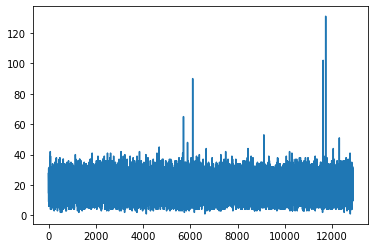

In [24]:
#re_text = re.sub(r"\S*\d\S*", '', joined_text).strip()
plt.plot(df_ads['num_words']);


In [25]:
""" 
w matches alphanumeric characters, which means a-z, A-Z, and 0-9. It also matches the underscore, _, and the dash, -.
d matches digits, which means 0-9.
s matches whitespace characters, which include the tab, new line, carriage return, and space characters.
S matches non-whitespace characters.
. matches any character except the new line character n.
#re_text = re.sub(r"\S*\d\S*", '', joined_text).strip()

TS-831XU-4G, 2910H8MAR-L-AZ-6, 090-15200-601)

s_email = re.search(r"\w\S*@.*\w", sender.group())
 
match ddd-ddd 
"""

' \nw matches alphanumeric characters, which means a-z, A-Z, and 0-9. It also matches the underscore, _, and the dash, -.\nd matches digits, which means 0-9.\ns matches whitespace characters, which include the tab, new line, carriage return, and space characters.\nS matches non-whitespace characters.\n. matches any character except the new line character n.\n#re_text = re.sub(r"\\S*\\d\\S*", \'\', joined_text).strip()\n\nTS-831XU-4G, 2910H8MAR-L-AZ-6, 090-15200-601)\n\ns_email = re.search(r"\\w\\S*@.*\\w", sender.group())\n \nmatch ddd-ddd \n'

In [26]:
## Remove all words with numbers; thought of just removing model numbers but for now all words containing numbers can be removed

#s = "090-15200-601) abc 3def"
#re.sub(r"\S*\d\S*", '', s).strip()

#re.sub(r"\d*-\d.*\s", '', s).strip()
#'091520601)

In [27]:
# find ads with numbers, preferably model numbers

#re.sub(r"\S*\d\S*", '', s).strip()

df_ads.loc[df_ads["ad"].str.contains(pat = "-[0-9]", regex = True)]



,ad,num_chars,num_words
9,Loyeen Pair Soundbar Wall Mount Bracket for Samsung HW-M360 HW-K550 HW-M550 HW-K650 HW-K430 HW-K335 HW-K651 HW-K450 AH61-04106A Sound bar Speaker Come with Mounting Screws Accessories,183,25
10,"Winegard TV-2900 82-Channel Weatherproof Transformer, Black",59,6
16,Orienttvbracket TV Wall Mount Bracket for most 14-40 Inch LED LCD OLED Plasma Flat Screen Panel with VESA up to 200x200mm and 55 lb,131,24
18,"MGO TV Wall Mounts for Most 19-42 Inch LCD LED Smart TV or Monitor, Universal Full Motion TV Mounts, Swivel Cantilever Mounting Holder Arm with Max VESA 200x200mm",162,28
42,New BN59-01301A Replaced Remote fit for Samsung TV N5300 NU6900 NU7100 NU7300 Series UN32N5300 UN32M4500 UN43NU6900 UN55NU6900 UN65NU6900 UN40NU7100 UN43NU7100 UN49NU7100 UN50NU7100 UN55NU7100,192,23
...,...,...,...
12859,"Themoemoe Kids Smartwatch Phone, Kids Music Watch Without GPS with Camera Music 7 Games Alarm Birthday Gift for Kids 3-14 Year Old (Pink)",137,23
12864,iGeeKid [2019 Upgrade Free SIM Card] Waterproof Smart Watch for Kids GPS Tracker Phone Watch for Boys Girls 3-12 Years Old with Two-Way Call SOS Anti-Lost Game Camera Cellphone Wrist Watch,188,31
12871,New AK59-00104R Remote contro for Samsung BD-D6100C/ZA BD-P1580 BD-P1590M BD-C6500 BD-C5500 BD-C6900 BD-C5900 BD-D6500/ZA BD-P1595 BD-P1600 BD-C6800/XAA BD-C6600/XAA Blu-ray DVD Player,184,21
12873,"Watbro Band Compatible with Garmin Forerunner 35, Soft Silicone Watch Band Replacement Strap, for Garmin Forerunner 35 Smart Watch, Fit 5.11-9.05 Inch (130mm-230mm) Wrist",170,24


### End of EDA. Prepare for Modeling - tokenizing, mapping tokens to numeric encodings

#### Deciding how many documents to use has been a big challenge. 
The orginal dataset consists of 2.7 million documents (rows) and a total corpus size of 31 million words across 40 categories. 

Neural networks require huge amounts of compute resources for model training. Using the GPU on Google Colab was 8 times faster than my local machine, but it eventually started running Out of Memory and the session would frequently crash mid-way. The Colab Pro plan would only take me marginally further. 

In addition to the number of documents, the batch_size makes a difference in the time and memory required and impacts the evaluation metrics of the model. I reduced the batch_size so that the training would need less memory, but it increased the loss (categorical_crossentropy) and reduced the categorical_accuracy. Another factor was using the Embedding layer in the model architecture. This sped up the training by about 40% and the evaluation metrics were marginally worse (not sure why, yet). 

Of course, the number of epochs in fitting is directly proportionaly to the time taken and I picked the number that maximised the categorical_accuracy. 

So essentially, the variables were number of documents and batch_size and the trade-off was the accuracy of the model. 

I wanted to use all 2 million documents as the corpus - it would have taken me <font color="red">5 years to train the model</font> on my local machine and <font color="red">8 months on Google Colab</font>! I would have run into OOM in any case. In fact, <font color="red">at 25k documents I started running into OOM</font>.

Hence, I  was able to to use only 13k (0.5%!) documents and I picked 2 categories (Electronics and Wearables) of the 40 in my Amazon dataset. 

The README has details on the timings and evaluation metrics for the 10K, 25K, 100K, 500K, 2M documents on both my local machine and Google Colab with GPU. 

I also experimented with various model parameters - 
number of nodes/neurons in the input layer, dimension of vectors in the Embedding layer, optimizer (Adam and RMSprop), numberof epochs for training, sequence length etc. I have chosen the optimal values after experimentation. 



In [28]:
# Keep 10% of df_ads for validation data 

df_ads_test = df_ads.sample(frac = 0.1, random_state=42)
 
# Create train df by dropping the test df rows

df_ads_train = df_ads.drop(df_ads_test.index)

In [29]:
#df_ads_train.head()

In [30]:
df_ads_test.reset_index( drop = True, inplace = True)
df_ads_test.head()

,ad,num_chars,num_words
0,Replacement Remote Control for Hisense Smart Internet TV EN-33925A 32K366W 40K366WB 32K20DW 32K20W 40H5 50K610GWN 55K610GWN XV5849 32H5B 40H5B 40K366WN,151,20
1,STRQUA G20 Remote Control 2.4G Wireless Voice Control Sensing Air Remote Mouse for PC Android TV Box (G20s Voice),113,19
2,GinCoband Fitbit Blaze Bands Replacement for Fitbit Blaze Smart Watch No Tracker 8 Color Large Small Women,106,17
3,"HDTV Antenna, 1byone Digital Indoor TV Antenna 25 Miles Range with 10ft High Performance Coax Cable, Extremely Soft Design and Lightweight",138,21
4,"VR Headset Virtual Reality Headset 3D Glasses with 120¬∞FOV, Anti-Blue-Light Lenses, Stereo Headset, for All Smartphones with Length Below 6.3 inch Such as iPhone & Samsung HTC HP LG etc.",187,30


In [31]:
#df_ads_test.drop(columns=['index'], inplace=True )
df_ads_test

,ad,num_chars,num_words
0,Replacement Remote Control for Hisense Smart Internet TV EN-33925A 32K366W 40K366WB 32K20DW 32K20W 40H5 50K610GWN 55K610GWN XV5849 32H5B 40H5B 40K366WN,151,20
1,STRQUA G20 Remote Control 2.4G Wireless Voice Control Sensing Air Remote Mouse for PC Android TV Box (G20s Voice),113,19
2,GinCoband Fitbit Blaze Bands Replacement for Fitbit Blaze Smart Watch No Tracker 8 Color Large Small Women,106,17
3,"HDTV Antenna, 1byone Digital Indoor TV Antenna 25 Miles Range with 10ft High Performance Coax Cable, Extremely Soft Design and Lightweight",138,21
4,"VR Headset Virtual Reality Headset 3D Glasses with 120¬∞FOV, Anti-Blue-Light Lenses, Stereo Headset, for All Smartphones with Length Below 6.3 inch Such as iPhone & Samsung HTC HP LG etc.",187,30
...,...,...,...
1283,"100 Inch Projection Screen 16:9 HD Portable Anti-Crease Foldable Indoor Outdoor Projector Movie Screen, Free Hooks",114,16
1284,POWERLITE 970 PROJ XGA 4000L (V11H865020),41,6
1285,Xiaomi Mi Band 4,16,4
1286,"Secbolt Leather Bands Compatible with Apple Watch Band 38mm 40mm iwatch Series 5 4 3 2 1, Slim Strap with Breathable Hole Replacement Wristband Women",149,25


In [32]:
# Convert from df to string for modeling. 
# Limit to max_rows (13k) to avoid OOM

ads_str_train = df_ads_train["ad"].to_string(header= False, index=False, max_rows=max_rows) 
ads_str_test = df_ads_test["ad"].to_string(header= False, index=False, max_rows=max_rows) 


In [33]:
# number of characters altogether: 4.5M
len(ads_str_train), len(ads_str_test)

(4068791, 309119)

In [34]:
# Check ads_str 
idx = 463575
print( ads_str_train[idx:idx+200])

NameError: name 'ads_str' is not defined

In [ ]:
idx = 0
str_to_find = "Sony"
cnt = ads_str_train.count( str_to_find)

for i in range (cnt): 
    idx = ads_str_train.find( str_to_find, idx+1)    
    if i // 20 == 0: # limit the number printed
        print( ads_str_train[idx:idx+200])


Sony STR-DH790 7.2-ch AV Receiver, 4K HDR, Dolby Vision, Dolby Atmos, dts:X, with Bluetooth
                                                                                                            
Sony HTC Smartphones
                                                                                                                                                                                   
Sony RMT-TX102U for RMT-TX100D RMT-TX101J RMT-TX101D RMT-TX100E RMT-TX101E RMT-TX200
                                                                                                                   
Sony DAV-TZ140 HBD-TZ140 DAV-TZ150 HBD-TZ145 DAV-TZ145 AV-RZ130 DAVTZ150 HBDTZ145 DAVTZ145 AVRZ130 DAVTZ140 HBDTZ140 Audio Vidio AV System RM-ADU101 DAV-TZ135
                                         
Sony Blu-ray XBOX360 PS4 HDTV DVD
                                                                                                                                                                  

In [35]:
# Make sure split contains similar data - Sony occurs 22 times in test and 296 in train, so looks good
idx = 0
str_to_find = "Sony"
cnt = ads_str_test.count( str_to_find)

for i in range (cnt): 
    idx = ads_str_test.find( str_to_find, idx+1)    
    #print( ads_str_test[idx:idx+200])


### For LSTM, we need to:
(These steps happen in preprocess_tokenize.py)
1. Tokenize - split the ad text into tokens (words)
2. Remove dups - create a list of distinct tokens
3. Since the model needs numeric values (not words), we map the tokens into numeric ids (used a simple index in the list as the ids). 
(The Keras Embedding layer does a semantics vectorization of the tokens, more later).  
And we maintain a dict to map the ids back into the tokens.  

The following steps happen in modeling_functions.py - Sequence object:   
    4. Create sequences of input tokens of length max_len (used 4, but configurable), followed by the 'labeled' token (or next word). 
 

In [36]:
# Sequences of length max_len=4 and step=3

max_len = 4
step = 3

# Tokenize
text_train = ProcessText( ads_str_train)
text_test = ProcessText( ads_str_test)

# Print number of tokens
text_train.tokens_info()
text_test.tokens_info()

# Create sequences
seq_train = Sequences(text_train, max_len, step)
seq_train.sequences_info()

# Print number of sequences
seq_test = Sequences(text_test, max_len, step)
seq_test.sequences_info()


total tokens: 290062, distinct tokens: 22726
total tokens: 31723, distinct tokens: 5424
number of sequences of length 16: 48341
number of sequences of length 16: 5285


In [37]:
len( text_train), len( text_test)

(22726, 5424)

In [38]:
# Print the first ten tokens and their numeric ids

print(text_train.tokens[:10])
print(text_train.tokens_ind[:10], '\n')

# View 2 sequences 
np.array(seq_train.sequences[:2])

['Eighwood', 'Dual', 'Band', 'UHF', 'VHF', 'Antenna', 'NMO', 'Mount', 'for', 'Car']
[2453, 12489, 18423, 11260, 14340, 5618, 14862, 18627, 17991, 10673] 



array([[ 2453, 12489, 18423, 11260, 14340,  5618, 14862, 18627, 17991,
        10673, 22038, 11501, 12416,  9558, 21922, 17273],
       [14862, 18627, 17991, 10673, 22038, 11501, 12416,  9558, 21922,
        17273,  6730, 22577,  2851,  6335, 16885, 20807]])

#### **Interpretation:**  
Each sequence is of length 4, of which 3 are input tokens (X variable) and the 4th is the output (y). This is a self-supervised learning algorithm, and the beauty is that we don't need an extra step of human intervention to label the data!   

Tokens and their numeric ids:   
['ZAGG', 'InvisibleShield', 'Luxe', 'Screen', 'Protector', 'for', 'Apple', 'Watch', 'Series', '2']  
[3393, 963, 9601, 18828, 12556, 10430, 5129, 544, 9532, 9217]   
3393 is the numeric id for Zagg; 963 is the numeric id for InvisibleShield etc...   

Sequence:   
array([[ 3393,   963,  9601, 18828],  
       [18828, 12556, 10430,  5129]])  
Sequence[0] contains: Zagg Invisible Luxe Screen  
Sequence[1] contains Screen Protector for Apple  


#### TextDataGenerator is a subclass of Keras's Sequence superclass used to generate the sequences required during fit.  
TextDataGenerator is called at each step during the model.fit and it returns a batch of sequences containing the X and y variables as defined above.     
  
X is a sparse matrix of shape: batch_size, sequence len, distinct token ids and  
y is of shape: batch_size, distinct token ids

In [39]:
# Create generator for training data 

params = {
  'sequence_length': max_len,
  'vocab_size': len(text_train),
  'batch_size': batch_size,
  'shuffle': True
}

train_generator = TextDataGenerator(seq_train.sequences, seq_train.next_words, **params)

In [40]:
# Create generator for testing data 

params_test = {
  'sequence_length': max_len,
  'vocab_size': len(text_test),
  'batch_size': batch_size,
  'shuffle': True
}

test_generator = TextDataGenerator(seq_test.sequences, seq_test.next_words, **params_test)

In [41]:
len(train_generator), train_generator.batch_size


(11, 4096)

In [42]:

len(test_generator), test_generator.batch_size


(1, 4096)

In [43]:
#train_generator.X.shape, train_generator.y.shape, 

### Model architecture: 
RNN model with LSTM input layer (with or without Embedding Layer) of 20k nodes (vocabulary size), Dropout to avoid overfitting and output layer using softmax activation.   
<font color="red">The output shape is the size of the vocabulary (20k)</font> which is very different from the 2 in a binary classification or 10 in the MNIST image 0-9 digit classification! 

In [44]:
def lstm_model(sequence_length, vocab_size, layer_size, embedding=False):
  
  # 4, 20k, 128
  print( sequence_length, vocab_size, layer_size)
  
  model = Sequential()
  if embedding:
    model.add(Embedding(vocab_size, layer_size))
    model.add(LSTM(layer_size))    
  else:
    model.add(LSTM(layer_size, input_shape=(sequence_length, vocab_size)))

  ## Second LSTM layer passes outputs forward to next layer
  #model.add(LSTM(layer_size, return_sequences=False))
  #model.add(Dense(layer_size, activation = 'relu', kernel_regularizer=l2(0.001)))
  model.add(Dropout(0.3))

  model.add(Dense(vocab_size, activation='softmax'))
  return model
  



#### 
Create the model and compile with optimizer RMSprop and metrics applicable for text generation:   
loss='categorical_crossentropy'   
metrics = ['CategoricalAccuracy', 'CategoricalCrossentropy', 'TopKCategoricalAccuracy', 'CategoricalHinge'])

Optionally, use TPU for the model training 

In [45]:

# Set useTPU (in global section at the top) to True to use the TPU. 

if useTPU: 

  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])

  tf.config.experimental_connect_to_cluster(tpu)
  tf.tpu.experimental.initialize_tpu_system(tpu)

  strategy = tf.distribute.TPUStrategy(tpu)
  #strategy = tf.distribute.experimental.TPUStrategy(tpu) # experimental is deprecated

  print("REPLICAS: ", strategy.num_replicas_in_sync)

  #
  # Create model with TPU strategy
  #
  with strategy.scope():
    
    print( "Doing create model with TPU")
    model = lstm_model(max_len, len(text_train), layer_size)
    optimizer = tf.keras.optimizers.Adam(learning_rate =0.01)
    #optimizer = tf.keras.optimizers.RMSprop(learning_rate =0.01)

    
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, 
              metrics = ['CategoricalAccuracy', 'CategoricalCrossentropy', 'TopKCategoricalAccuracy', 'CategoricalHinge'])

else: 
    
  print( "Doing create model without TPU")
  model = lstm_model(max_len, len(text_train), layer_size)
  
  # Tried both RMSprop/Adam as optimizer
  optimizer = tf.keras.optimizers.Adam(learning_rate =0.01)
#  optimizer = tf.keras.optimizers.RMSprop(learning_rate =0.01)

  # Metrics applicable for text generation
  model.compile(loss='categorical_crossentropy', optimizer=optimizer, 
              metrics = ['CategoricalAccuracy', 'CategoricalCrossentropy', 'TopKCategoricalAccuracy', 'CategoricalHinge'])


Doing create model without TPU
16 22726 128


2022-05-12 22:20:44.413330: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [46]:
model.summary() # 14 million trainable params! 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 128)               11701760  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 22726)             2931654   
                                                                 
Total params: 14,633,414
Trainable params: 14,633,414
Non-trainable params: 0
_________________________________________________________________


### Model.fit 
train_generator is called at each step and it returns a batch of X and y.   
Using the test_generator should work for the validation data, but it gives an error. 

In [47]:
def model_fit( num_epochs):

  history = model.fit(train_generator,
          steps_per_epoch=len(train_generator),
          epochs=num_epochs,
#         validation_data = test_generator, 
          verbose=1)

  return history 


Baseline metrics: No training; 1 epoch 

In [48]:
# get baseline first
baseline_history = model_fit( 1 )


11/11 [==============================] - 425s 38s/step - loss: 7.7029 - categorical_accuracy: 0.0438 - categorical_crossentropy: 7.7029 - top_k_categorical_accuracy: 0.1356 - categorical_hinge: 1.0256


In [285]:
#baseline_history.history

In [232]:
# train model, 100 epochs gives better results
history = model_fit( 100)
#history = model_fit( 60)


Epoch 1/60
23/23 [==============================] - 144s 6s/step - loss: 6.2617 - categorical_accuracy: 0.0918 - categorical_crossentropy: 6.2617 - top_k_categorical_accuracy: 0.2277 - categorical_hinge: 1.0490
Epoch 2/60
23/23 [==============================] - 142s 6s/step - loss: 5.6373 - categorical_accuracy: 0.1446 - categorical_crossentropy: 5.6373 - top_k_categorical_accuracy: 0.3139 - categorical_hinge: 1.0460
Epoch 3/60
23/23 [==============================] - 144s 6s/step - loss: 5.1502 - categorical_accuracy: 0.1955 - categorical_crossentropy: 5.1502 - top_k_categorical_accuracy: 0.3777 - categorical_hinge: 1.0302
Epoch 4/60
23/23 [==============================] - 147s 6s/step - loss: 4.7562 - categorical_accuracy: 0.2346 - categorical_crossentropy: 4.7562 - top_k_categorical_accuracy: 0.4271 - categorical_hinge: 1.0127
Epoch 5/60
23/23 [==============================] - 156s 7s/step - loss: 4.4250 - categorical_accuracy: 0.2681 - categorical_crossentropy: 4.4250 - top_k_ca

KeyboardInterrupt: 

In [286]:
# Save the model for inference purposes
model.save('../data/lstm_model_13krows_batch4k.h5')


### Modeling done! 
Evaluate the model performance with graphs and metrics vs baseline

In [293]:
# Plot loss and accuracy metrics 

def plot_metrics(history, title):
  fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize = (14,6))

  ## Plot Training & Validation Loss
  ax1.plot(history.history['loss'], label="Training Loss")
  #ax1.plot(history.history['val_loss'], label="Testing Loss")
  ax1.legend();

  ## Plot Training & Validation Accuracy
  ax2.plot(history.history['categorical_accuracy'], label="Training Cat Accuracy")
  #ax2.plot(history.history['val_accuracy'], label="Testing Accuracy")
  ax2.legend();

  ax3.plot(history.history['top_k_categorical_accuracy'], label="Training TopKCatAccuracy")
  ax3.legend();

  ax4.plot(history.history['categorical_hinge'], label="Training categorical_hinge")
  ax4.legend();

  plt.suptitle(title);


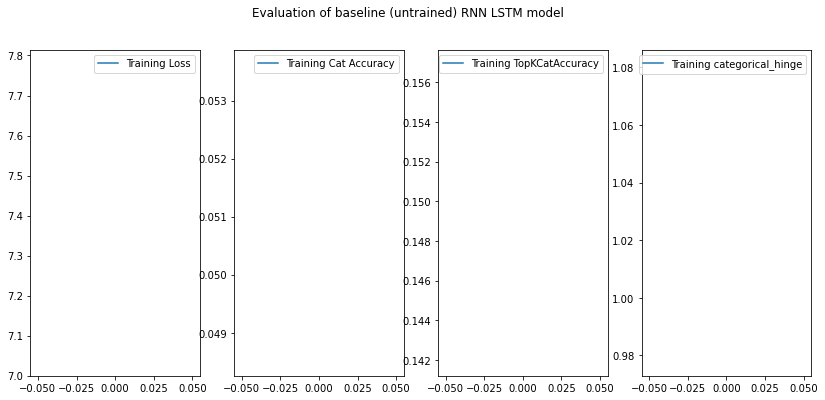

In [294]:
plot_metrics(baseline_history, "Evaluation of baseline (untrained) RNN LSTM model")
# only 1 epoch so no history for graph


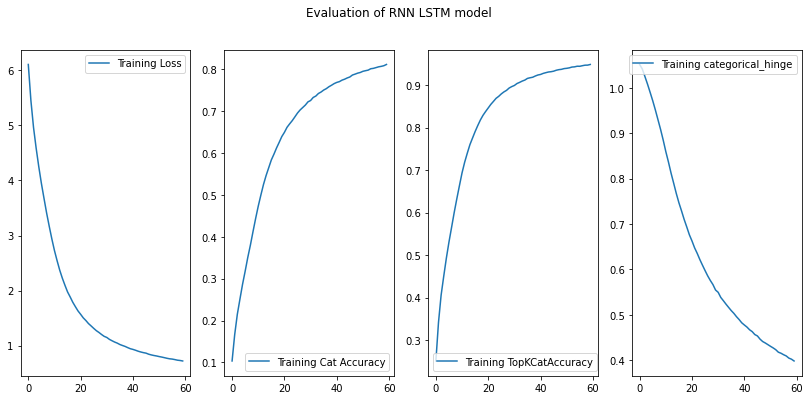

In [ ]:
plot_metrics(history, "Evaluation of RNN LSTM model")

#### **Interpretation:**  
The graphs are trending in the right direction - the loss is decreasing as the epochs increase and the categorical and TopK Categorical Accuracies are increasing.   
They are plateauing as the epochs increase, but maybe with more epochs they could be better.   
Validation data was giving an error so I couldn't plot the validation loss and accuracy which would have helped check for overfitting. 


In [303]:
#model.score()
#train_generator.vocab_size
df_ads_train.shape, df_ads.shape


((11592, 3), (12880, 3))

#### Compute model evaluation metrics 

In [304]:
def evaluate_model(baseline_history, history):

  results_df = pd.DataFrame()

  results_df["max_rows"] = [max_rows]
  results_df["Actual Rows"] = [df_ads_train.shape]
  results_df["batch_size"] = [train_generator.batch_size]

  total_tokens, distinct_tokens = text_train.tokens_info()
  #print( total_tokens, distinct_tokens)

  results_df["total_tokens"] = [total_tokens]
  results_df["distinct_tokens"] = [distinct_tokens]
  results_df["steps_per_epoch"] = [len(train_generator)]

  results_df["Baseline Categorical Accuracy"] = max(baseline_history.history['categorical_accuracy'])
  results_df["Categorical Accuracy"] = max(history.history['categorical_accuracy'])

  results_df["Baseline Categorical Crossentropy"] = min(baseline_history.history['categorical_crossentropy']) #Loss
  results_df["Categorical Crossentropy"] = min(history.history['categorical_crossentropy']) #Loss
  
  results_df["Baseline Top K Categorical Accuracy"] = max(baseline_history.history['top_k_categorical_accuracy'])
  results_df["Top K Categorical Accuracy"] = max(history.history['top_k_categorical_accuracy'])

  return results_df




#### Write metrics to file

In [ ]:
results_df = evaluate_model(baseline_history,  history)

results_df["Model"]= ["LSTM"]*len(results_df)

# save the metric results to file
results_df.to_csv("../data/lstm_results_df_holidays.csv")


total tokens: 321785, distinct tokens: 24101


In [309]:
results_df

NameError: name 'results_df' is not defined

#### **Interpretation:**

Much better than baseline. 


In [ ]:
'''
nn= KerasClassifier(build_fn=model_func, epochs=10, batch_size=32, validation_data=(X_test_sc, y_test), verbose=0)

#nn4= KerasRegressor(build_fn=model_func_deep, epochs=10, batch_size=512, validation_data=(X_test_sc, y_test), verbose=0)

params = {
    "input_shape": [X_train_sc[0].shape], 
    "hidden_layers": [2, 3, 4], 
    "hidden_neurons": [8, 16, 32], 
    "dropout": [None, 0.3],
    "epochs": [40, 60, 80]
}

gs_nn = GridSearchCV(estimator=nn, param_grid=params, cv=3, n_jobs=-1)

gs_nn.fit( X_train_sc, y_train)

# Make predictions 

y_train_preds = gs_nn.predict(X_train_sc)
y_test_preds = gs_nn.predict(X_test_sc)
preds_prob = gs_nn.predict_proba(X_test_sc)[:,1] # 2nd column has the predicted prob of majority class

results_df = evaluate_classification_model(gs_nn, y_test_preds, preds_prob)

results_df["Model"]= ["Sequential"]*len(results_df)
results_df["Best Params"]= str(gs_nn.best_params_)

# save the classification metric results to file. 
results_df.to_csv("./data/c_seq_results_df.csv")

print( f"Training Accuracy score: {metrics.accuracy_score( y_train, y_train_preds)}")
print( f"Test Accuracy score: {metrics.accuracy_score( y_test, y_test_preds)}")

print( f"Best Params: {gs_nn.best_params_}")

'''

'\nnn= KerasClassifier(build_fn=model_func, epochs=10, batch_size=32, validation_data=(X_test_sc, y_test), verbose=0)\n\n#nn4= KerasRegressor(build_fn=model_func_deep, epochs=10, batch_size=512, validation_data=(X_test_sc, y_test), verbose=0)\n\nparams = {\n    "input_shape": [X_train_sc[0].shape], \n    "hidden_layers": [2, 3, 4], \n    "hidden_neurons": [8, 16, 32], \n    "dropout": [None, 0.3],\n    "epochs": [40, 60, 80]\n}\n\ngs_nn = GridSearchCV(estimator=nn, param_grid=params, cv=3, n_jobs=-1)\n\ngs_nn.fit( X_train_sc, y_train)\n\n# Make predictions \n\ny_train_preds = gs_nn.predict(X_train_sc)\ny_test_preds = gs_nn.predict(X_test_sc)\npreds_prob = gs_nn.predict_proba(X_test_sc)[:,1] # 2nd column has the predicted prob of majority class\n\nresults_df = evaluate_classification_model(gs_nn, y_test_preds, preds_prob)\n\nresults_df["Model"]= ["Sequential"]*len(results_df)\nresults_df["Best Params"]= str(gs_nn.best_params_)\n\n# save the classification metric results to file. \nresul

### Now comes the fun part! Inference.
Let's generate some text and see what results we get. 


In [ ]:
# Specify the input prompt. This can be a few words with keywords for the ad. 
# Examples are: Last minute Memorial Day deals on Samsung headphones' or the others commented out below. 

input_prefix = 'Last minute Memorial Day deals on Samsung headphones'
#input_prefix = 'Apple watch'
#input_prefix = 'Mothers Day savings on'
#input_prefix = 'Big savings on the new'

#input_prefix = 'Sony TV'
#input_prefix = 'Sony PS3'
#input_prefix = 'Sony Playstation' 

token2ind, ind2token = text_train.token2ind, text_train.ind2token
text_prefix = ProcessText(input_prefix, token2ind, ind2token)

tokenizing. Going to preprocess...
In pre-processing


#### First instantiate an instance of the class ModelPredict (defined in modeling_functions.py), passing in the input prompt and the trained model. 


In [ ]:
pred = ModelPredict(model, text_prefix, token2ind, ind2token, max_len)


### Let's see the generated text for different temperatures. 

Temperature controls the randomness of the generated text. A value of 0 makes the engine deterministic, which means that it will always generate the same output for a given input text. A value of 1 makes the engine take the most risks and use a lot of creativity.

#### Temperature sampling is inspired by statistical thermodynamics, where high temperature means low energy states are more likely encountered.
In probability models, logits play the role of energy and we can implement temperature sampling by dividing logits by the temperature before feeding them into softmax and obtaining our sampling probabilities.



In [ ]:
#### generate_sequence calls the trained models's .predict function after converting the input words to their numeric ids 
# and vice versa after the models prediction. It also handles temperature. 

temperatures = [1, 0.7, 0.4, 0.1]

for temperature in temperatures:
  print('temperature:', temperature)
  print(pred.generate_sequence(30, temperature=temperature))
  print('\n')

temperature: 1
Last minute Memorial Day deals on Samsung headphones and HT Audio/Video Jewelry Charging 1080P 38mm Watch Wristband All 1 Watch Galaxy RV Series Series Rose 3 with iWatch Series 40mm Fitbit Ace Apple 42mm Series Watch Smart [2019


temperature: 0.7
Last minute Memorial Day deals on Samsung headphones Blu Watch Screen, NTSC Stainless,, Replacement 38mm 42mm SM Series Sports M/L 1 Series Band 38mm Men No Watch Watch Watch Leather 4 and 1, [Scratch


temperature: 0.4
Last minute Memorial Day deals on Samsung headphones Leather, Band, 4 Series Series Band Series Series Series 4 Series Series Band Series Series Series 4 Band 38mm Series HR Series Band 38mm, Series Band Series


temperature: 0.1
Last minute Memorial Day deals on Samsung headphones,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,




#### **Interpretation:**  
At lower temperature, there may be repitition of words. Typically, results are best with temperature 0.7.   

The ad text generated is decent! 
In fact, given that our training data size is not large, the results are a lot better than I had expected. 

However, other Generative Pre-trained Transformer models like OpenAI's GPT-3 and Eleuther's GPT-NEO are trained on 800+GB of data and do a really good job of generating text. 

We will compare our model's output with these models after the Embedding section below. 



### LSTM with Embedding layer

#### Now try with Embedding Layer



In [310]:
batch_size_emb = batch_size

params_emb = params.copy()
params_emb['embedding'] = True

train_generator_emb = TextDataGenerator(seq_train.sequences, seq_train.next_words, **params_emb)

In [ ]:
# Tried 128, 64 and 16 as vector dimensions, 128 is best. 
 
model_emb = lstm_model(max_len, len(text_train), layer_size, embedding=True)
#model_emb = lstm_model(max_len, len(text_train), 128, embedding=True)

# model_emb = lstm_model(max_len, len(text_train), 64, embedding=True): Gives error while predicting??

model_emb.compile(loss='categorical_crossentropy', optimizer=optimizer, 
              metrics = ['CategoricalAccuracy', 'CategoricalCrossentropy', 'TopKCategoricalAccuracy', 'CategoricalHinge'])


4 24101 128


In [ ]:
model_emb.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 128)         3084928   
                                                                 
 lstm_6 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 24101)             3109029   
                                                                 
Total params: 6,325,541
Trainable params: 6,325,541
Non-trainable params: 0
_________________________________________________________________


In [ ]:
def emb_model_fit( num_epochs):
  history_emb = model_emb.fit(train_generator_emb,
              steps_per_epoch=len(train_generator_emb),
              epochs=num_epochs,
              verbose=1)
  return history_emb


In [ ]:

# get baseline first with just 1 epoch (no training)
emb_baseline_history = emb_model_fit( 1 )


26/26 [==============================] - 13s 432ms/step - loss: 7.1986 - categorical_accuracy: 0.0545 - categorical_crossentropy: 7.1986 - top_k_categorical_accuracy: 0.1586 - categorical_hinge: 1.0347


In [ ]:
emb_history = emb_model_fit( 100 )
#emb_history = emb_model_fit( 140 )

Epoch 1/100
26/26 [==============================] - 11s 423ms/step - loss: 5.9922 - categorical_accuracy: 0.1106 - categorical_crossentropy: 5.9922 - top_k_categorical_accuracy: 0.2587 - categorical_hinge: 1.0433
Epoch 2/100
26/26 [==============================] - 11s 425ms/step - loss: 5.2847 - categorical_accuracy: 0.1836 - categorical_crossentropy: 5.2847 - top_k_categorical_accuracy: 0.3597 - categorical_hinge: 1.0291
Epoch 3/100
26/26 [==============================] - 11s 425ms/step - loss: 4.7866 - categorical_accuracy: 0.2310 - categorical_crossentropy: 4.7866 - top_k_categorical_accuracy: 0.4226 - categorical_hinge: 1.0173
Epoch 4/100
26/26 [==============================] - 11s 435ms/step - loss: 4.4037 - categorical_accuracy: 0.2643 - categorical_crossentropy: 4.4037 - top_k_categorical_accuracy: 0.4673 - categorical_hinge: 1.0031
Epoch 5/100
26/26 [==============================] - 12s 438ms/step - loss: 4.0780 - categorical_accuracy: 0.2949 - categorical_crossentropy: 4.

In [ ]:
model_emb.save('../data/lstm_model_emb_13k_batch4k.h5')


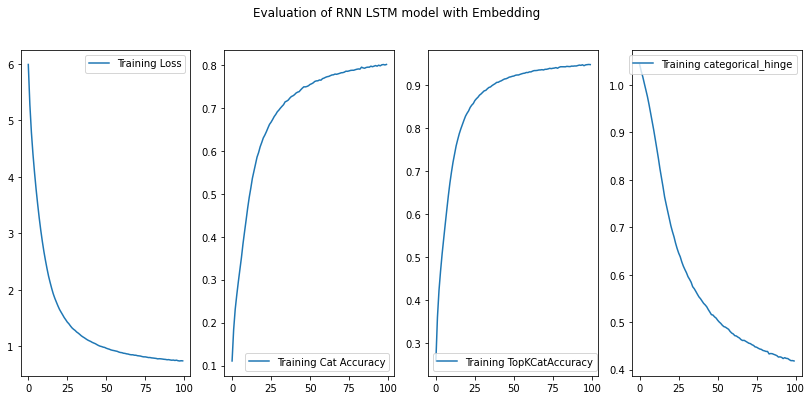

In [ ]:

plot_metrics(emb_history, "Evaluation of RNN LSTM model with Embedding ")

In [179]:

emb_results_df = evaluate_model(emb_baseline_history,  emb_history)
#results_df = evaluate_classification_model(gs_nn, y_test_preds, preds_prob)

emb_results_df["Model"]= ["Embed LSTM"]*len(emb_results_df)
#results_df["Best Params"]= str(gs_nn.best_params_)

results_df_merged = results_df.append(emb_results_df)

# save the metric results to file
results_df_merged.to_csv("../data/lstm_results_df_holidays.csv")


total tokens: 321785, distinct tokens: 24101


In [180]:
emb_results_df


,max_rows,Actual Rows,batch_size,total_tokens,distinct_tokens,steps_per_epoch,Baseline Categorical Accuracy,Categorical Accuracy,Baseline Categorical Crossentropy,Categorical Crossentropy,Baseline Top K Categorical Accuracy,Top K Categorical Accuracy,Model
0,15000,15000,4096,321785,24101,26,0.054518,0.801683,7.198565,0.741645,0.158597,0.947463,Embed LSTM


In [181]:
results_df_merged

,max_rows,Actual Rows,batch_size,total_tokens,distinct_tokens,steps_per_epoch,Baseline Categorical Accuracy,Categorical Accuracy,Baseline Categorical Crossentropy,Categorical Crossentropy,Baseline Top K Categorical Accuracy,Top K Categorical Accuracy,Model
0,15000,15000,4096,321785,24101,26,0.054284,0.812021,7.322841,0.722696,0.154457,0.948843,LSTM
0,15000,15000,4096,321785,24101,26,0.054518,0.801683,7.198565,0.741645,0.158597,0.947463,Embed LSTM


In [182]:
token2ind, ind2token = text_train.token2ind, text_train.ind2token


input_prefix = 'Sony camera'

#input_prefix = 'Alilang'
#input_prefix = 'Bridal Wedding'


text_prefix = ProcessText(input_prefix, token2ind, ind2token)

tokenizing. Going to preprocess...
In pre-processing


In [183]:
pred_emb = ModelPredict(model_emb, text_prefix, token2ind, ind2token, max_len, embedding=True)


In [184]:
temperatures = [1, 0.7, 0.4, 0.1]

for temperature in temperatures:
  print('temperature:', temperature)
  print(pred_emb.generate_sequence(50, temperature=temperature))
  print('\n')

temperature: 1
Sony camera KDL- F550 LG Charge, HDMI, USB, USB, USB SD Protect SD Card Slot USB SD NTSC Accessories for VHF AV USB Wireless Pedometer for Fitbit Charge Charger,, Replacement USB Charging Dock for Fitbit Inspire and Inspire Fitness Tracker IP68 Sleep & Pedometer Calorie


temperature: 0.7
Sony camera KDL-, Smart Band, Built- in with Battery, Laptop, Cable, Vizio,,,,,,,,,,, Adjustable,,,,,,,,,,,,,,,,,, and,,


temperature: 0.4
Sony camera KDL- series, Active,, Apple, and Apple, and,,,,,,,,,,,,,, 20mm, Nylon, Fenix 3/Fenix 5X, 4/3/2/1, Rose Gold, Black, Black, 42mm/44mm- Black 3D and 3D


temperature: 0.1
Sony camera KDL- series,,, and Gear S3 Bands, Woven Bands, Soft Soft Silicone Bands for Gear Fit2 Pro Bands, 22mm Soft Leather Watch Band for Samsung Gear Fit2 Pro Bands, 22mm 22mm Watch Band for Gear S3 Frontier, Gear S3 Frontier Bands 22mm




#### Dig deep into the calculations of the next word and temperature math. Will clean this up and output the top 5 words along with the probabilities to show how termperature affects the next word picked

In [ ]:
text_prefix.tokens_ind

[6668, 20331]

In [ ]:
#text_prefix
single_sequence_1 = np.zeros((1, max_len, len(token2ind)), dtype=bool)
prefix_1 = text_prefix.tokens_ind[-max_len:]

for i, s in enumerate(prefix_1):
    single_sequence_1[0, i, s] = 1


#pred_emb.model_predict(100)

In [ ]:
single_sequence_1[0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:
model_input = np.array(text_prefix.tokens_ind).reshape(1,-1)
model_input[0] # token ids for our input prefix token

array([ 6668, 20331])

In [ ]:

prob = model_emb.predict(model_input)[0]
prob # next word probabilities of each of the tokens in vocab

array([9.5121388e-05, 2.6356524e-13, 3.2048091e-14, ..., 2.7757497e-13,
       2.7559988e-13, 2.7797659e-13], dtype=float32)

In [ ]:
np.sort(prob)[::-1] # see the probabiities
#sum(pred)

array([4.2082691e-01, 1.8160506e-01, 1.3039681e-01, ..., 1.2126692e-22,
       3.7879435e-23, 2.5100658e-23], dtype=float32)

In [ ]:
temperature = 1
prob_with_temperature = np.exp(np.where(prob == 0, 0, np.log(prob + 1e-10)) / temperature)

In [ ]:

prob_with_temperature
prob_with_temperature /= np.sum(prob_with_temperature)

In [ ]:
prob_with_temperature
np.sort(prob_with_temperature)[::-1]


array([4.2082602e-01, 1.8160465e-01, 1.3039654e-01, ..., 9.9999849e-11,
       9.9999849e-11, 9.9999849e-11], dtype=float32)

In [ ]:
# Get random index based on its probability; NOT the highest probability
next_word = np.random.choice(len(prob_with_temperature), p=prob_with_temperature)


In [ ]:
len(prob_with_temperature)

22586

In [ ]:
# random word (index) chosen based on probability

next_word

15922

In [ ]:
# what was the probability at this index? 
prob_with_temperature[15922] # not bad  - second highest probability

0.18160465

In [ ]:
# convert index back to token (word)
ind2token[next_word]

'Series'

In [ ]:

# what is the index (and then token) of the highest probability: 0.42082602
np.where(prob_with_temperature==0.42082602)


(array([872]),)

In [ ]:

ind2token[872]

'Band'

In [185]:
# Draw graphs of probability distributions of corpus 
'''
predictions= model.predict()
plt.bar(dictionary,predictions)
plt.show()
'''

'\npredictions= model.predict()\nplt.bar(dictionary,predictions)\nplt.show()\n'

### Compare with the pre-trained GPT2 model

The original GPT-2 model released by OpenAI was trained on English webpages linked to from Reddit, with a strong bias toward longform content (multiple paragraphs).  
It generates good (coherent) sentences but since it is not tuned for advertisements, it doesn't generate native Amazon ads like our model does. 

In [95]:
# From Hugging Face transformers 

# OpenAI's GPT-2 pre-trained model
gpt2_generator = pipeline("text-generation")


No model was supplied, defaulted to gpt2 (https://huggingface.co/gpt2)


In [272]:


#from transformers import AutoTokenizer, AutoModelForCausalLM

# tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-j-6B")
#model = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-j-6B")

### Compare with EleutherAI's pre-trained GPT-NEO-1.3B model
It is a GPT2 like causal language model trained on the 800GB 
<a href="https://pile.eleuther.ai/" target="_blank">Pile Dataset</a> (Wikipedia, Common Crawl, GitHub, Stack Exchange, YouTube, Enron emails, PubMed, US Patents, Project Gutenberg and a few more)

Would have liked to use their gpt-j-6B model but it is too resource intensive (25GB to download the pre-trained model weights, 48GB of CPU RAM to just load the model, 96GB of GPU RAM for training/fine-tuning!). 

#### Try out various parameters to tune the generated output: 

**Greedy search** simply selects the token with the highest probability as its next word.
However, if we always sample the most likely word, the standard language model training objective causes us to get stuck in loops like “I don’t know. I don’t know. I don’t know.”

**do_sample:** Whether or not to use sampling, use greedy decoding otherwise.

**Temperature, top-k, top-p, repetition_penalty**  (explained below)




In [99]:
# EleutherAI/gpt-neo-1.3B is manageable at 5GB model weights download

from transformers import pipeline
gpt_neo_generator = pipeline('text-generation', model='EleutherAI/gpt-neo-1.3B')


In [100]:
s = gpt_neo_generator("Sony TV", do_sample=True, min_length=50)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [101]:
# View output generated for the input
s[0]['generated_text']

'Sony TV will take “the world” by storm.\n\nIn my opinion, Sony is the greatest company to have invested in televisions and video technology. They are one of the most powerful producers and marketers of televisions because they have'

#### Temperature sampling is inspired by statistical thermodynamics, where high temperature means low energy states are more likely encountered.
In probability models, logits play the role of energy and we can implement temperature sampling by dividing logits by the temperature before feeding them into softmax and obtaining our sampling probabilities.

•	Low-temperature results in extremely repetitive and predictable text, but where the local structure is highly realistic: in particular, all words (a word being a local pattern of characters) are real words from the corpus.


In [273]:
s = gpt_neo_generator("Mothers Day discounts for Apple watch", temperature = 0.7, top_p = 0.9, top_k=20)
s[0]['generated_text']


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'Mothers Day discounts for Apple watch, Samsung Galaxy S7 and S7 Edge\n\nApple Watch is the latest product of Apple Inc. The smartwatch is the latest in the line of Apple products. It is a smartwatch which is available in'

#### In Top-K sampling, the K most likely next words are filtered and the probability mass is redistributed among only those K next words.
#### To apply the Top-k sampling, all the tokens are sorted according to the probabilities and the probabilities for anything below the k’th token are zeroed out.

In [103]:
gpt_neo_generator("Apple Watch", temperature = 0.7, top_k=20)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Apple Watch and Apple Pay in the United States\n\nApple Watch is one of the most popular wearable devices in the world. Apple Watch has been introduced in the United States since it launched on December 21, 2017. Apple Pay has been introduced in the'}]

#### Top-P Sampling (Nucleus sampling): Another way to exclude very low probability tokens is to include the most probable tokens that make up the “nucleus” of the probability mass function (PMF), such that the sum of the most probable tokens just reaches p. In other words, based on a parameter 0<=p<=1, Top-P Sampling aggregates the smallest set of words that have summed probability mass p. It can be thought of as a variation of top-k sampling with dynamic k. 

In [263]:
gpt_neo_generator("Best deals on Samsung", temperature = 0.7, top_p = 0.9)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Best deals on Samsung Galaxy S8 and S8+\n\nSamsung Galaxy S8 and S8+ have become the best phones of 2018. The latest phones come with an upgraded design, new features, better performance, and much more. So,'}]

#### repetition_penalty
The more a token is used within generation the more it is penalized to not be picked in successive generation passes.


In [264]:
gpt_neo_generator("Best deals on Samsung", temperature = 0.7, top_p = 0.9, top_k=20, repetition_penalty=3.0)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Best deals on Samsung Galaxy S8 and S8 Plus\n\nWe have been writing about the best Samsung smartphones for years. We know how much you love your phone, so we are here to help you with the best deals on the latest models of'}]

In [98]:
# Compare with GPT-2
gpt2_generator("Apple Watch", temperature = 0.7, top_p = 0.9, top_k=20, repetition_penalty=3.0)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Apple Watch 2.0, Apple\'s new watch OS for iOS and Android that will run on the latest version of Google Now or any other supported smartphone operating system until January 1st 2014 (see below).\n "We\'ve seen an uptick in usage'}]

In [275]:
# num_return_sequences causes multiple outputs to be generated

gpt2_generator("AmazonBasics", temperature = 0.7, top_p = 0.9, top_k=20, repetition_penalty=3.0, num_return_sequences=3)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'AmazonBasics\nThe following table describes the current state of this product. The values for "Total Product Value" are listed by their respective name in red text, which is a list that represents total units produced or sold (as defined above). For'},
 {'generated_text': 'AmazonBasics.com\n"I\'m very happy to have found this site," said Mark Purdy, co-founder and CEO of the company\'s online store that has been a major supporter since it was launched in October 2011."We were all'},
 {'generated_text': "AmazonBasics.com\nI've used the code from this post and it's been quite good so far: http://blog/jr_mueller-1128682301"}]

### Ooh, check this out! 

In [88]:
# Download my fine-tuned model which is published to HuggingFace! 

ad_text_generator = pipeline('text-generation', model='nirajsaran/AdTextGenerator')


In [116]:
# Do inference! This performs faster than my in-memory trained model! 
# And it supports all the additional parameters, including those not available through the GUI on the HuggingFace site: 
# https://huggingface.co/nirajsaran/AdTextGenerator

ad_text_generator("Last minute deals Christmas deals on Sony TV", do_sample = True, temperature=0.8, top_p = 0.9, top_k=5, repetition_penalty=3.0, num_return_sequences=3)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Last minute deals Christmas deals on Sony TV'},
 {'generated_text': 'Last minute deals Christmas deals on Sony TV'},
 {'generated_text': 'Last minute deals Christmas deals on Sony TV and Android Devices'}]

#### **Interpretation**: 
The Large Language Models like GPT-2 and GPT_NEO etc do really well on the text they're trained on, with zero-shot learning. 
However, they are not suitable for my use case of generating the text for advertisements in the format that Amazon ads typically have. 

They do claim to have "few-shot learning", where you can provide prompts in a line or two and it learns from this minimal training data to generate similar output content. I have not found it generate ad text, especialy for Amazon ads. 

My fine-tuned model works quite well on the Electronics and Wearables categories on which it has been fine-tuned. There are, however, occasional hallucinations, though the ad copy is mostly coherent.

In other domains, it doesn't do quite as well...
Tesla for Christmas today
Honda on sale

The last area to try out is to fine-tune these pre-trained models with my dataset i.e. the pre-trained model is trained via repeated graident updates at the end of each epoch using a largish corpus of example texts. This involves updating the weights of a pre-trained model by training on a supervised dataset specific to the desired task of generating ad text for Amazon. 

This is done in the next notebook 


### End of notebook